# RiMEA 07: Demographic Parameters

This notebook implements the current public approximation of RiMEA Test 7 for adult demographic walking speeds. It uses a $70\,\mathrm{m} \times 20\,\mathrm{m}$ corridor, staggers 50 one-agent sources over time to suppress congestion, and compares assigned and observed speeds across the age groups from the RiMEA table.

Reference table used here:

- 20 y.o.: 10 agents, $1.60$-$1.64\,\mathrm{m/s}$
- 30 y.o.: 10 agents, $1.52$-$1.56\,\mathrm{m/s}$
- 40 y.o.: 10 agents, $1.46$-$1.50\,\mathrm{m/s}$
- 50 y.o.: 10 agents, $1.39$-$1.43\,\mathrm{m/s}$
- 60 y.o.: 5 agents, $1.27\,\mathrm{m/s}$
- 70 y.o.: 5 agents, $1.07\,\mathrm{m/s}$


In [1]:
import json
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy

from scenario_builders.rimea07_demographic import AGE_GROUPS, WALKABLE_AREA_WKT, build_distribution_specs, build_raw_scenario
from core.scenario import load_scenario, run_scenario


In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8fafc",
        "axes.edgecolor": "#334155",
        "axes.labelcolor": "#0f172a",
        "axes.titleweight": "bold",
        "xtick.color": "#0f172a",
        "ytick.color": "#0f172a",
        "font.size": 11,
    }
)

AGE_COLORS = {
    20: "#2563EB",
    30: "#0891B2",
    40: "#10B981",
    50: "#F59E0B",
    60: "#F97316",
    70: "#DC2626",
}

FRAME_STEP = 10
SNAPSHOT_PERCENTILES = (20, 50, 80)


## Scenario Setup

Each source represents one agent with a deterministic age and assigned desired speed. The sources are spawned in order over time, which makes it possible to recover the age bucket from the trajectory start order while keeping the corridor mostly uncongested.

In [3]:
raw = build_raw_scenario(seed=42, max_simulation_time=140.0)
specs = build_distribution_specs()
reference = pd.DataFrame(AGE_GROUPS)

tmpdir = tempfile.TemporaryDirectory()
scenario_dir = Path(tmpdir.name)
(scenario_dir / "config.json").write_text(json.dumps(raw, indent=2), encoding="utf-8")
(scenario_dir / "geometry.wkt").write_text(WALKABLE_AREA_WKT, encoding="utf-8")

scenario = load_scenario(str(scenario_dir))
print(scenario.summary())
reference


Scenario: /private/var/folders/xp/t78pqmf50rb4s9vh6gdz0ykr0000gq/T/tmp65ocwjv0
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      140.0s
  Exits:         1
  Distributions: 50
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~50
  Journey elems: 1
  Route:         0 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-exits_0
    jps-distributions_0: 1 agents (flow: 0.0-1.0s)
    jps-distributions_1: 1 agents (flow: 0.5-1.5s)
    jps-distributions_2: 1 agents (flow: 1.0-2.0s)
    jps-distributions_3: 1 agents (flow: 1.5-2.5s)
    jps-distributions_4: 1 agents (flow: 2.0-3.0s)
    jps-distributions_5: 1 agents (flow: 2.5-3.5s)
    jps-distributions_6: 1 agents (flow: 3.0-4.0s)
    jps-distributions_7: 1 agents (flow: 3.5-4.5s)
    jps-distributions_8: 1 agents (flow: 4.0-5.0s)
    jps-distributions_9: 1 agents (flow: 4.5-5.5s)
    jps-distributions_10: 1 agents (flow: 5.0-6.0s)
    jps-distributions_11: 1 agents (flow: 5.5-6.5s)
   

,age_years,count,vmin,vmax
0,20,10,1.60,1.64
1,30,10,1.52,1.56
2,40,10,1.46,1.50
3,50,10,1.39,1.43
4,60,5,1.27,1.27
5,70,5,1.07,1.07


## Run the Corridor Simulation

In [4]:
%%capture
result = run_scenario(scenario, seed=42)


In [5]:
traj_df = result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy()
traj = pedpy.TrajectoryData(traj_df, frame_rate=result.frame_rate)
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)

speed_df = pedpy.compute_individual_speed(
    traj_data=traj,
    frame_step=FRAME_STEP,
    speed_calculation=pedpy.SpeedCalculation.BORDER_EXCLUDE,
)
traj_with_speed = traj.data.merge(speed_df[["id", "frame", "speed"]], on=["id", "frame"], how="left")

first_samples = (
    traj.data.sort_values(["frame", "id"])
    .groupby("id", as_index=False)
    .first()
    .sort_values(["frame", "y", "x"])
    .reset_index(drop=True)
)
agent_assignment = first_samples[["id", "frame"]].copy()
agent_assignment["age_years"] = [spec["age_years"] for spec in specs]
agent_assignment["assigned_speed"] = [spec["assigned_speed"] for spec in specs]
agent_assignment["flow_start_time"] = [spec["flow_start_time"] for spec in specs]

agent_rows = []
for row in agent_assignment.itertuples(index=False):
    settled = speed_df[(speed_df["id"] == row.id) & (speed_df["frame"] >= row.frame + 20)]
    if settled.empty:
        settled = speed_df[speed_df["id"] == row.id]
    agent_rows.append(
        {
            "id": int(row.id),
            "age_years": int(row.age_years),
            "assigned_speed": float(row.assigned_speed),
            "observed_speed": float(settled["speed"].median()),
            "spawn_frame": int(row.frame),
            "spawn_time": float(row.frame / result.frame_rate),
        }
    )

agent_stats = pd.DataFrame(agent_rows)
age_summary = (
    agent_stats.groupby("age_years", as_index=False)
    .agg(
        assigned_mean=("assigned_speed", "mean"),
        observed_mean=("observed_speed", "mean"),
        observed_std=("observed_speed", "std"),
        count=("id", "count"),
    )
)

print(f"Evacuation time: {result.evacuation_time:.2f} s")
print(f"Agents remaining: {result.agents_remaining}")
age_summary


Evacuation time: 89.57 s
Agents remaining: 0


,age_years,assigned_mean,observed_mean,observed_std,count
0,20,1.62,1.615672,1.240517e-02,10
1,30,1.54,1.538766,1.251361e-02,10
2,40,1.48,1.479194,1.384962e-02,10
3,50,1.41,1.409202,1.265639e-02,10
4,60,1.27,1.270000,3.256222e-09,5
5,70,1.07,1.070000,1.805362e-08,5


## Speed Versus Age

The grey bands show the RiMEA reference min/max range for each age group. Blue markers are the deterministic assigned speeds and colored markers show the observed median free-flow speed per agent.

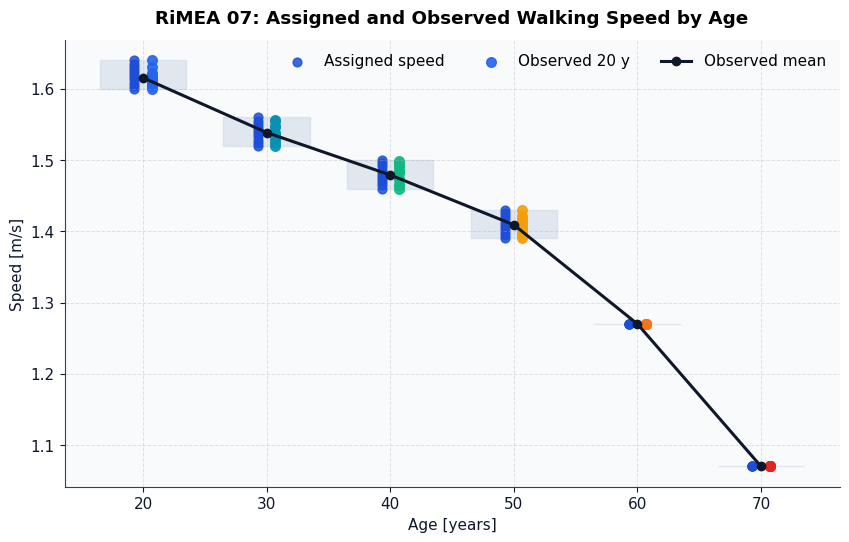

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.8))

for row in reference.itertuples(index=False):
    ax.fill_between(
        [row.age_years - 3.5, row.age_years + 3.5],
        [row.vmin, row.vmin],
        [row.vmax, row.vmax],
        color="#CBD5E1",
        alpha=0.5,
    )

ax.scatter(
    agent_stats["age_years"] - 0.7,
    agent_stats["assigned_speed"],
    color="#1D4ED8",
    s=40,
    alpha=0.85,
    label="Assigned speed",
)

for age, rows in agent_stats.groupby("age_years"):
    ax.scatter(
        rows["age_years"] + 0.7,
        rows["observed_speed"],
        color=AGE_COLORS[age],
        s=48,
        alpha=0.9,
        label=f"Observed {age} y" if age == 20 else None,
    )

ax.plot(age_summary["age_years"], age_summary["observed_mean"], color="#0F172A", linewidth=2.2, marker="o", label="Observed mean")
ax.set_title("RiMEA 07: Assigned and Observed Walking Speed by Age", pad=12)
ax.set_xlabel("Age [years]")
ax.set_ylabel("Speed [m/s]")
ax.set_xticks(reference["age_years"])
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="upper right")
plt.show()


## Observed Speed Distribution Per Age Group

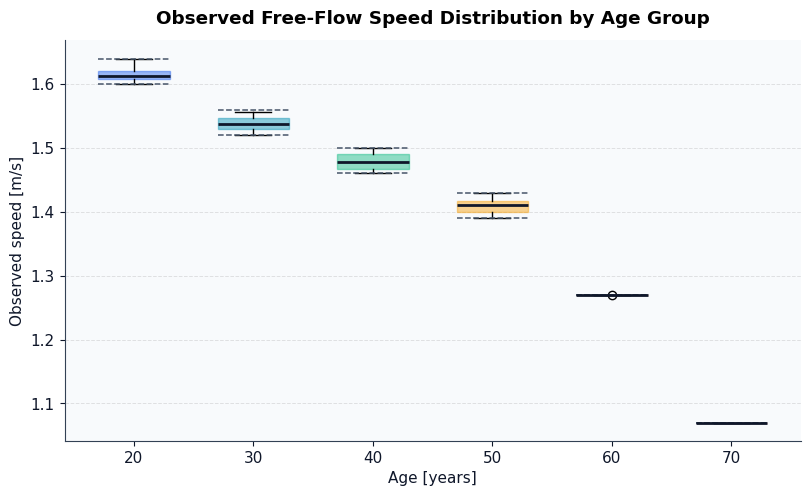

In [7]:
ages = sorted(agent_stats["age_years"].unique())
box_data = [agent_stats.loc[agent_stats["age_years"] == age, "observed_speed"].to_numpy() for age in ages]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
box = ax.boxplot(box_data, positions=ages, widths=6.0, patch_artist=True)
for patch, age in zip(box["boxes"], ages):
    patch.set_facecolor(AGE_COLORS[age])
    patch.set_alpha(0.45)
    patch.set_edgecolor(AGE_COLORS[age])
for item in box["medians"]:
    item.set_color("#0F172A")
    item.set_linewidth(2)

for row in reference.itertuples(index=False):
    ax.hlines([row.vmin, row.vmax], row.age_years - 3.0, row.age_years + 3.0, colors="#475569", linestyles="--", linewidth=1.1)

ax.set_title("Observed Free-Flow Speed Distribution by Age Group", pad=12)
ax.set_xlabel("Age [years]")
ax.set_ylabel("Observed speed [m/s]")
ax.set_xticks(ages)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## Spawn Timing and Trajectory Overview

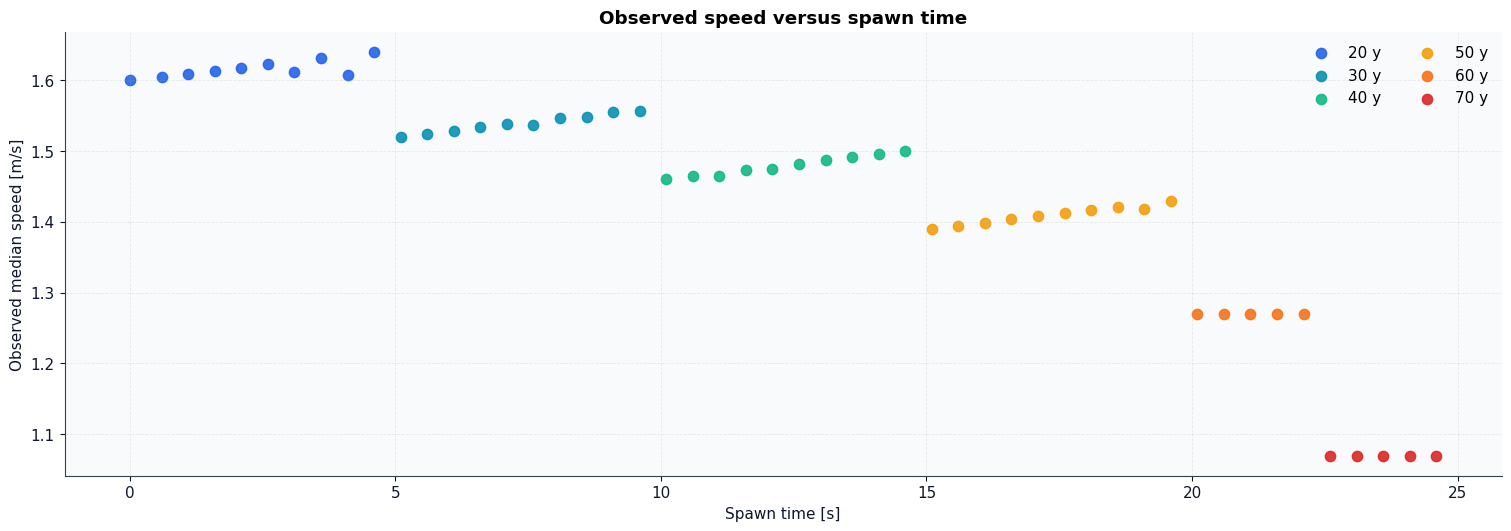

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5.2), constrained_layout=True)

for age, rows in agent_stats.groupby("age_years"):
    ax.scatter(rows["spawn_time"], rows["observed_speed"], s=55, color=AGE_COLORS[age], alpha=0.9, label=f"{age} y")
ax.set_title("Observed speed versus spawn time")
ax.set_xlabel("Spawn time [s]")
ax.set_ylabel("Observed median speed [m/s]")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=2)
plt.show()


In [ ]:
result.cleanup()
tmpdir.cleanup()